In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

df=pd.read_csv("data/raw/investments_VC.csv", encoding="latin1")
df.columns = df.columns.str.strip()

In [48]:
df.shape

(54294, 39)

In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   permalink             49438 non-null  str    
 1   name                  49437 non-null  str    
 2   homepage_url          45989 non-null  str    
 3   category_list         45477 non-null  str    
 4   market                45470 non-null  str    
 5   funding_total_usd     49438 non-null  str    
 6   status                48124 non-null  str    
 7   country_code          44165 non-null  str    
 8   state_code            30161 non-null  str    
 9   region                44165 non-null  str    
 10  city                  43322 non-null  str    
 11  funding_rounds        49438 non-null  float64
 12  founded_at            38554 non-null  str    
 13  founded_month         38482 non-null  str    
 14  founded_quarter       38482 non-null  str    
 15  founded_year          38482 no

In [50]:
df.head()

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,"17,50,000",acquired,USA,NY,New York City,New York,1.0,2012-06-01,2012-06,2012-Q2,2012.0,2012-06-30,2012-06-30,1750000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,"40,00,000",operating,USA,CA,Los Angeles,Los Angeles,2.0,NaN,NaN,NaN,NaN,2010-06-04,2010-09-23,0.0,4000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,"40,000",operating,EST,NaN,Tallinn,Tallinn,1.0,2012-10-26,2012-10,2012-Q4,2012.0,2012-08-09,2012-08-09,40000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,/organization/in-touch-network,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,"15,00,000",operating,GBR,NaN,London,London,1.0,2011-04-01,2011-04,2011-Q2,2011.0,2011-04-01,2011-04-01,1500000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,/organization/r-ranch-and-mine,-R- Ranch and Mine,NaN,|Tourism|Entertainment|Games|,Tourism,"60,000",operating,USA,TX,Dallas,Fort Worth,2.0,2014-01-01,2014-01,2014-Q1,2014.0,2014-08-17,2014-09-26,0.0,0.0,60000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [51]:
df.describe()

,funding_rounds,founded_year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
count,49438.000000,38482.000000,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04
mean,1.696205,2007.359129,2.173215e+05,7.501051e+06,6.163322e+03,1.302213e+05,2.336410e+04,1.888157e+06,6.541898e+04,1.628453e+05,2.074286e+06,6.088736e+05,4.434360e+05,3.845592e+04,7.074227e+03,1.243955e+06,1.492891e+06,1.205356e+06,7.375261e+05,3.424682e+05,1.697692e+05,5.767067e+04,1.423197e+04
std,1.294213,7.579203,1.056985e+06,2.847112e+07,1.999048e+05,2.981404e+06,1.432046e+06,1.382046e+08,6.582908e+05,5.612088e+06,3.167231e+07,2.678348e+07,3.428169e+07,3.864461e+06,4.282166e+05,5.531974e+06,7.472704e+06,7.993592e+06,9.815218e+06,5.406915e+06,6.277905e+06,5.252312e+06,2.716865e+06
min,1.000000,1902.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000,2006.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.000000,2010.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2.000000,2012.000000,2.500000e+04,5.000000e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,18.000000,2014.000000,1.300000e+08,2.351000e+09,2.500000e+07,2.924328e+08,3.000000e+08,3.007950e+10,6.359026e+07,7.505000e+08,3.500000e+09,4.700000e+09,5.800000e+09,6.806116e+08,7.200000e+07,3.190000e+08,5.420000e+08,4.900000e+08,1.200000e+09,4.000000e+08,1.060000e+09,1.000000e+09,6.000000e+08


This dataset contains a lot of missing values , mostly founding details  | country code,state code are all missing

Missing values in categorical features may be treated as a separate "Missing" category.
Missing target values (`status`) should not be inferred from other features.

In [52]:
df.isnull().sum()


permalink                4856
name                     4857
homepage_url             8305
category_list            8817
market                   8824
funding_total_usd        4856
status                   6170
country_code            10129
state_code              24133
region                  10129
city                    10972
funding_rounds           4856
founded_at              15740
founded_month           15812
founded_quarter         15812
founded_year            15812
first_funding_at         4856
last_funding_at          4856
seed                     4856
venture                  4856
equity_crowdfunding      4856
undisclosed              4856
convertible_note         4856
debt_financing           4856
angel                    4856
grant                    4856
private_equity           4856
post_ipo_equity          4856
post_ipo_debt            4856
secondary_market         4856
product_crowdfunding     4856
round_A                  4856
round_B                  4856
round_C   

## Duplicate Analysis

The dataset contains 4855 duplicate rows.

Further investigation revealed that these duplicates originate from approximately 4856 completely empty records present at the end of the dataset.

These rows contain missing values across all columns and do not represent actual startup observations.

They will be removed during the data cleaning stage.

In [71]:
df.duplicated().sum()

np.int64(4855)

In [77]:
df["permalink"].duplicated().sum()

np.int64(4857)

In [78]:
df[df["permalink"].isna()].shape

(4856, 39)

In [79]:
df[df.duplicated()].head()

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
49439,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49440,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49441,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49443,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
(df==0).sum()

permalink                   0
name                        0
homepage_url                0
category_list               0
market                      0
funding_total_usd           0
status                      0
country_code                0
state_code                  0
region                      0
city                        0
funding_rounds              0
founded_at                  0
founded_month               0
founded_quarter             0
founded_year                0
first_funding_at            0
last_funding_at             0
seed                    35598
venture                 26161
equity_crowdfunding     48916
undisclosed             48486
convertible_note        48881
debt_financing          45213
angel                   46309
grant                   48296
private_equity          48065
post_ipo_equity         49122
post_ipo_debt           49363
secondary_market        49419
product_crowdfunding    49225
round_A                 40435
round_B                 43991
round_C   

Most of the companies are in operating category , some are missing too 

In [54]:
df["status"].value_counts(dropna=False)

status
operating    41829
NaN           6170
acquired      3692
closed        2603
Name: count, dtype: int64

Mostly the data comprises of software companies

In [64]:
df["market"].value_counts().head(20)

market
Software                4620
Biotechnology           3688
Mobile                  1983
E-Commerce              1805
Curated Web             1655
Enterprise Software     1280
Health Care             1207
Clean Technology        1200
Games                   1182
Hardware + Software     1081
Advertising             1064
Health and Wellness      920
Social Media             876
Finance                  867
Education                863
Manufacturing            744
Analytics                617
Security                 526
Semiconductors           507
Consulting               483
Name: count, dtype: int64

In [66]:
df["category_list"].head(20)

0            |Entertainment|Politics|Social Media|News|
1                                               |Games|
2                                |Publishing|Education|
3     |Electronics|Guides|Coffee|Restaurants|Music|i...
4                         |Tourism|Entertainment|Games|
5                                            |Software|
6                                         |Advertising|
7                                         |Curated Web|
8                                            |Software|
9                                               |Games|
10                                         |E-Commerce|
11                       |Entertainment|Games|Software|
12                                |Health and Wellness|
13                                |Health and Wellness|
14                                        |Real Estate|
15                                          |Education|
16                                         |E-Commerce|
17                                             |

Most of the companies are from USA,GBR,CAN , and at the same lot of the companies dont have countries mentioned  

In [61]:
df["country_code"].value_counts(dropna=False).head(20)

country_code
USA    28793
NaN    10129
GBR     2642
CAN     1405
CHN     1239
DEU      968
FRA      866
IND      849
ISR      682
ESP      549
RUS      368
SWE      315
AUS      314
ITA      308
NLD      307
IRL      306
SGP      299
BRA      293
CHL      285
JPN      284
Name: count, dtype: int64

In [67]:
df[df["status"].isna()].head()

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
5,/organization/club-domains,.Club Domains,http://nic.club/,|Software|,Software,"70,00,000",NaN,USA,FL,Ft. Lauderdale,Oakland Park,1.0,2011-10-10,2011-10,2011-Q4,2011.0,2013-05-31,2013-05-31,0.0,7000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7000000.0,0.0,0.0,0.0,0.0,0.0,0.0
67,/organization/1c-company,1C Company,http://1c.ru/eng,|Video Games|Games|Software|,Software,"20,00,00,000",NaN,RUS,NaN,Moscow,Moscow,1.0,1991-01-01,1991-01,1991-Q1,1991.0,2011-10-03,2011-10-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,200000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
89,/organization/1st-merchant-funding,1st Merchant Funding,http://www.1stmerchantfunding.com/,|Financial Services|,Financial Services,"1,00,00,000",NaN,USA,FL,Miami,Miami,1.0,2007-01-01,2007-01,2007-Q1,2007.0,2014-05-07,2014-05-07,0.0,0.0,0.0,0.0,0.0,10000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
121,/organization/24h00,24h00,http://www.boosket.com/,NaN,NaN,-,NaN,FRA,NaN,Paris,Paris,1.0,2006-01-01,2006-01,2006-Q1,2006.0,2006-08-01,2006-08-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
238,/organization/3nder,3nder,http://www.3nderapp.com,|iOS|Online Dating|Mobile|Location Based Servi...,Social Media,-,NaN,NaN,NaN,NaN,NaN,1.0,2014-02-18,2014-02,2014-Q1,2014.0,2014-05-09,2014-05-09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Features to engineer:

days_to_first_funding = first_funding_at - founded_at
startup_age
market_missing
category_missing
country_missing
single_funding_event = (first_funding_at == last_funding_at)
funding_stage_reached (ordinal: none → seed → A → B) — capped deliberately at B. This replaces raw round_B amount and stops the model from treating "reached B" as a crystal ball.
has_institutional_vc (binary, derived from venture being nonzero) — captures "professional investors are in" without leaking the cumulative dollar amount.

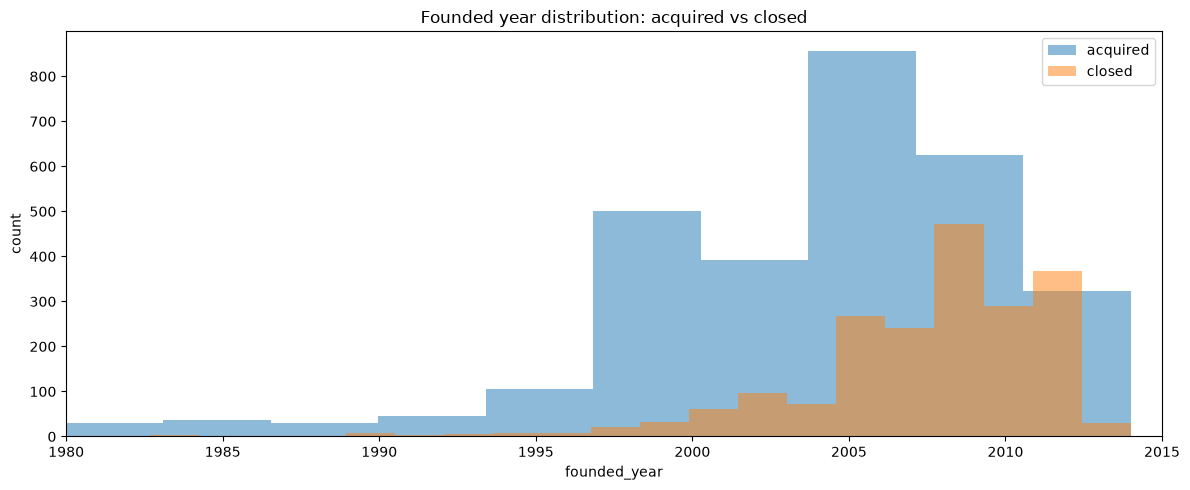

In [72]:
# restrict to labeled rows for this one
labeled = df[df["status"].isin(["acquired", "closed"])].copy()

plt.figure(figsize=(12, 5))
for s in ["acquired", "closed"]:
    subset = labeled[labeled["status"] == s]
    plt.hist(subset["founded_year"].dropna(), bins=30, alpha=0.5, label=s)
plt.xlabel("founded_year")
plt.ylabel("count")
plt.title("Founded year distribution: acquired vs closed")
plt.legend()
plt.xlim(1980, 2015)  # dataset is old, tail years are near-empty and skew the axis
plt.tight_layout()
plt.show()

## OBSERVATION

acquired companies peak around 2004-2007, closed companies peak a bit later around 2008-2011.
acquisitions take time to happen so newer companies havent had the chance yet, but closing down can happen fast. 
Backs up the idea that operating shouldnt be treated as a clean 3rd class, its just not resolved yet

                 market  category_list  country_code
market         1.000000       0.999526      0.556423
category_list  0.999526       1.000000      0.556255
country_code   0.556423       0.556255      1.000000


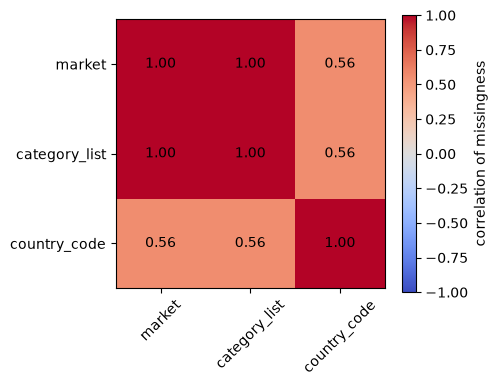

In [73]:
cols = ["market", "category_list", "country_code"]
missing_matrix = df[cols].isnull().astype(int)

# simple correlation of "missingness" across these 3 columns
corr = missing_matrix.corr()
print(corr)

plt.figure(figsize=(5, 4))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(cols)), cols, rotation=45)
plt.yticks(range(len(cols)), cols)
plt.colorbar(label="correlation of missingness")
for i in range(len(cols)):
    for j in range(len(cols)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center")
plt.tight_layout()
plt.show()

## OBSERVATIONS

market and category_list are missing together almost every time (corr ~1.00) but
country_code missingness doesnt match them as closely (corr ~0.56). 

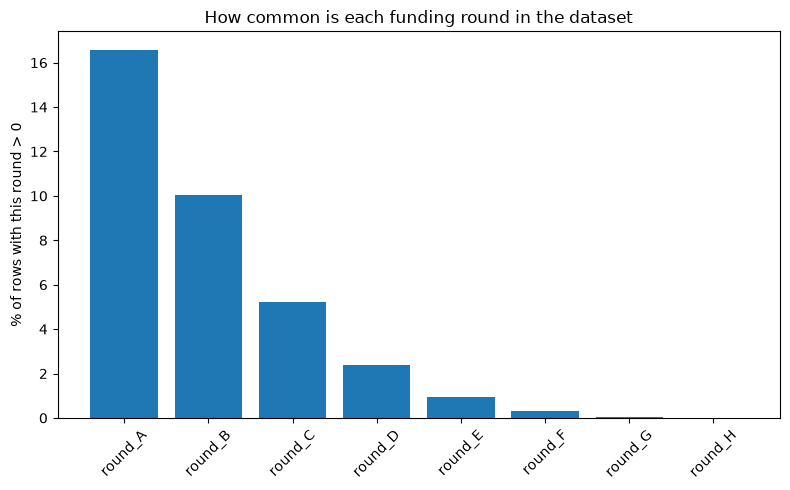

round_A    16.581943
round_B    10.032416
round_C     5.225255
round_D     2.372269
round_E     0.950381
round_F     0.316794
round_G     0.062622
round_H     0.007367
dtype: float64


In [80]:
round_cols = ["round_A", "round_B", "round_C", "round_D", "round_E", "round_F", "round_G", "round_H"]
nonzero_pct = (df[round_cols] > 0).sum() / len(df) * 100

plt.figure(figsize=(8, 5))
plt.bar(nonzero_pct.index, nonzero_pct.values)
plt.ylabel("% of rows with this round > 0")
plt.title("How common is each funding round in the dataset")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(nonzero_pct)

## OBSERVATIONS

Most of them have reached round A but rarely G 

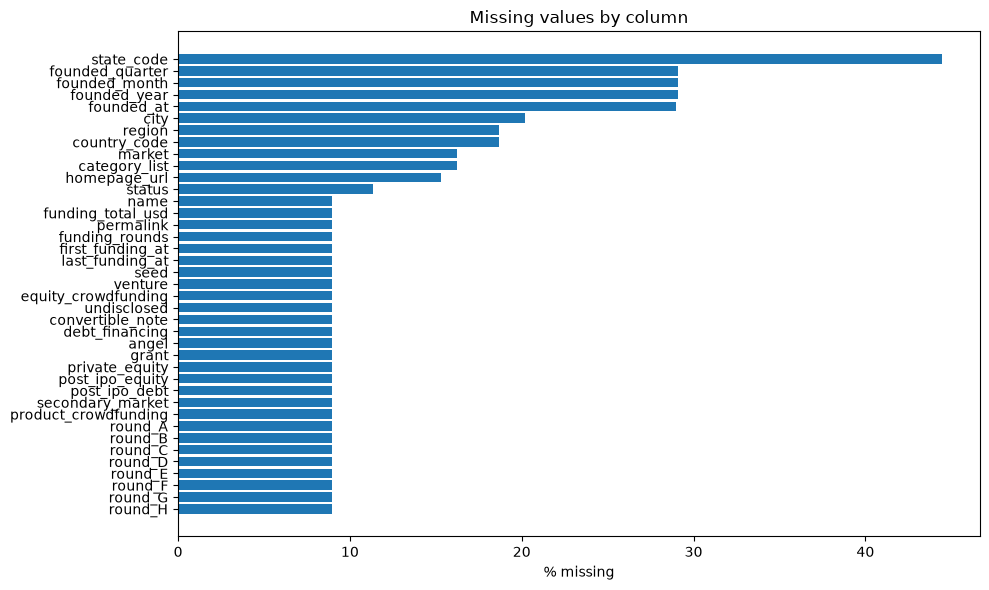

In [76]:
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(10, 6))
plt.barh(missing_pct.index, missing_pct.values)
plt.xlabel("% missing")
plt.title("Missing values by column")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## OBSERVATIONS

state_code is missing the most (~44%)
founded_at/month/quarter (~29%) 
city/region/country_code (~19-20%)